In [15]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [16]:

# Load the RFM dataset

DATA_DIR = Path("../data")

rfm = pd.read_csv(DATA_DIR / "olist_rfm.csv")

print(rfm.head())
print(rfm.shape)
print(rfm["churn"].value_counts(normalize=True))

                 customer_unique_id  recency  frequency  monetary  churn
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90      0
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19      0
2  0000f46a3911fa3c0805444483337064      586          1     86.22      1
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62      1
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89      1
(96096, 5)
churn
1    0.711289
0    0.288711
Name: proportion, dtype: float64


In [17]:

# Select features and target variable

X = rfm[['frequency',
        'monetary',
        'avg_order_value',
        'log_monetary',
        'is_repeat_customer',
        'high_spender']]
y = rfm["churn"]

In [18]:

# Split the data into training and testing sets
# 80% is used for training and 20% is used for testing.
# stratify=y keeps the same churn/non-churn ratio in both sets.


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (76876, 2)
Testing set: (19220, 2)


In [19]:

# Scale the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:

# Train the Logistic Regression model

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [21]:

# y_pred gives the predicted class,and y_prob gives the probability of churn.

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [22]:

# Evaluate the model

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print(f"\nAUC-ROC Score: {auc:.4f}")

Confusion Matrix:
[[  382  5167]
 [  869 12802]]

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.07      0.11      5549
           1       0.71      0.94      0.81     13671

    accuracy                           0.69     19220
   macro avg       0.51      0.50      0.46     19220
weighted avg       0.59      0.69      0.61     19220


AUC-ROC Score: 0.5102


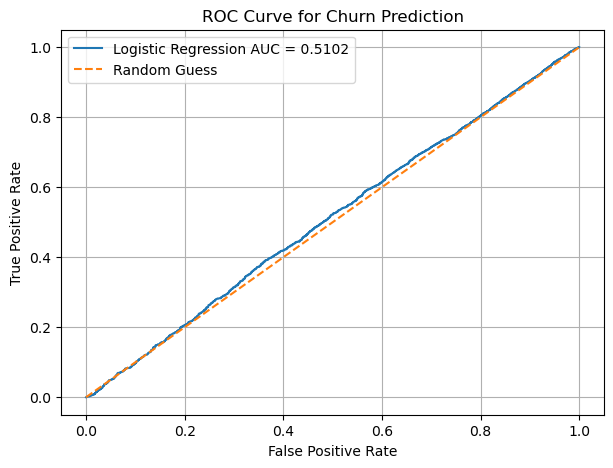

In [23]:

# Plot ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Churn Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [24]:

# model coefficients: Positive coefficient increases chance of churn, and negative coefficient decreases chance of churn.


coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df.sort_values(by="Coefficient", ascending=False))

     Feature  Coefficient
1   monetary    -0.006469
0  frequency    -0.033031


In [25]:

# Save predictions for report 
results = X_test.copy()
results["actual_churn"] = y_test.values
results["predicted_churn"] = y_pred
results["churn_probability"] = y_prob

results.to_csv(DATA_DIR / "logistic_regression_churn_predictions.csv", index=False)

print(results.head())

       frequency  monetary  actual_churn  predicted_churn  churn_probability
63817          1    162.41             1                1           0.501519
16965          1    111.02             1                1           0.501644
75828          1    195.00             1                1           0.501440
94243          1    213.73             1                1           0.501395
9383           1     56.78             1                1           0.501776
